## Linear Regression on House Price Dataset

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/houseprice.csv')

# Display the first 5 rows of the dataset
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Display basic information about the dataset
print(df.info())

# Display descriptive statistics
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Data Preprocessing

Before applying linear regression, we need to handle any missing values, convert categorical features, and select the appropriate features and target variable. For simplicity, we'll drop rows with missing values and consider numerical features for the model. You might need more sophisticated preprocessing depending on your data.

In [ ]:
# Handle missing values by dropping rows with any missing data (you might choose a different strategy like imputation)
df_cleaned = df.dropna()

# Select features (X) and target (y)
# Assuming 'Price' is the target variable and other numerical columns are features.
# You might need to adjust column names based on your actual dataset.

# Identify numerical columns for features
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Assuming 'SalePrice' or similar is your target column. Please change if different.
if 'SalePrice' in numerical_cols:
    target_column = 'SalePrice'
elif 'price' in numerical_cols:
    target_column = 'price'
elif 'Price' in numerical_cols:
    target_column = 'Price'
else:
    # Fallback if specific target column not found, choose the last numerical column
    target_column = numerical_cols[-1]
    print(f"Warning: 'SalePrice', 'price', or 'Price' not found. Using '{target_column}' as target.")

features = [col for col in numerical_cols if col != target_column]

X = df_cleaned[features]
y = df_cleaned[target_column]

print(f"Selected features: {features}")
print(f"Selected target: {target_column}")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Selected features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Selected target: price
Shape of X: (545, 5), Shape of y: (545,)


### Split Data into Training and Testing Sets

We split the data to evaluate the model's performance on unseen data. A common split is 80% for training and 20% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (436, 5), y_train shape: (436,)
X_test shape: (109, 5), y_test shape: (109,)


### Train the Linear Regression Model

Now, we'll train a Linear Regression model using the training data.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Model training complete.
Model coefficients: [3.08866956e+02 1.51246751e+05 1.18573171e+06 4.95100763e+05
 3.37660830e+05]
Model intercept: 51999.67680883873


### Make Predictions and Evaluate the Model

Finally, we'll use the trained model to make predictions on the test set and evaluate its performance using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display some actual vs predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results_df.head())

Mean Absolute Error (MAE): 1127483.35
Mean Squared Error (MSE): 2292721545725.36
Root Mean Squared Error (RMSE): 1514173.55
R-squared (R2): 0.55


,Actual,Predicted
316,4060000,6.178628e+06
77,6650000,6.370141e+06
360,3710000,3.283148e+06
90,6440000,4.226008e+06
493,2800000,3.409686e+06


### Visualizing Actual vs. Predicted Values

Let's visualize the actual house prices against the predicted house prices to get a better understanding of the model's performance.

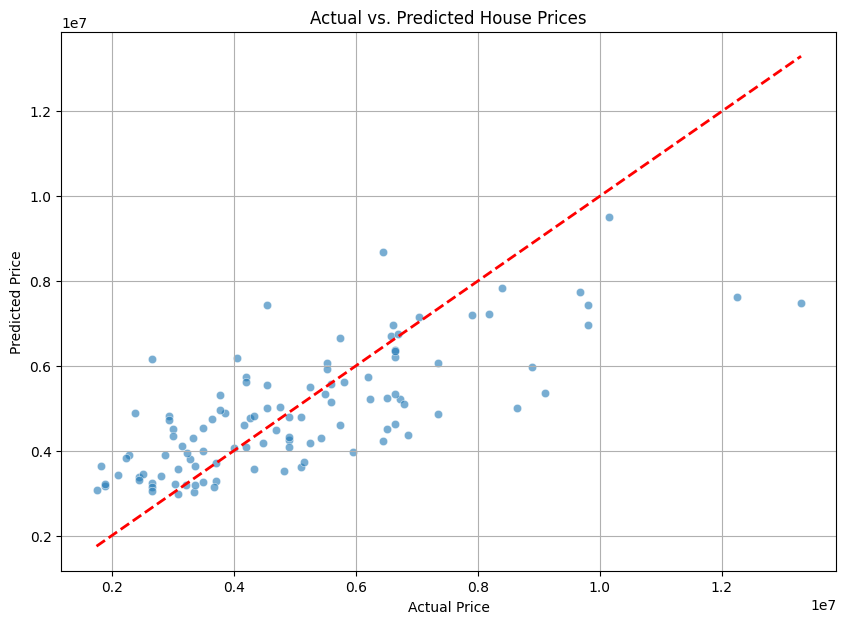

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.grid(True)
plt.show()